# Yolo v3

In [1]:
%pip install ultralytics
# gradio opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 기본 경로 설정 및 모델 불러오기

In [2]:
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
 
#========== 경로 설정 ==========
weights_path = "yolo/yolov3.weights"
config_path = "yolo/yolov3.cfg"
names_path = "yolo/coco.names"

#========== 라벨(이름) 가져오기 ==========
with open(names_path, "r", encoding='utf-8') as name_file:
    label_list = name_file.read().strip().split("\n")
    # strip : 공백 제거 / split: 줄마다 잘라서 리스트로
print(label_list)

#========== 모델 불러오기 ==========
net = cv2.dnn.readNet(weights_path, config_path)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


### cv2.dnn.readNet


OpenCV의 딥러닝 모듈(DNN)에서 **사전 학습된 신경망 모델을 로드**하는 함수입니다.

#### 기본 문법

```python
net = cv2.dnn.readNet(model, config="", framework="")
```

| 매개변수 | 설명 |
|---------|------|
| `model` | 가중치 파일 경로 (`.weights`, `.pb`, `.onnx` 등) |
| `config` | 네트워크 구조 파일 경로 (`.cfg`, `.pbtxt` 등) |
| `framework` | 프레임워크 명시 (보통 자동 감지) |

#### YOLO v3에서의 사용 예시

```python
weights_path = "yolo/yolov3.weights"
config_path  = "yolo/yolov3.cfg"

net = cv2.dnn.readNet(weights_path, config_path)
```

- `yolov3.weights` → 학습된 가중치 (모델의 실제 파라미터)
- `yolov3.cfg`     → 네트워크 아키텍처 정의 (레이어 구조)

#### 주요 역할

1. **모델 파싱** — Darknet, TensorFlow, ONNX 등 다양한 프레임워크 형식을 자동 감지하여 로드
2. **CPU/GPU 백엔드 설정** — 로드 후 실행 장치 지정 가능

   ```python
   net.setPreferableBackend(cv2.dnn.DNN_BACKEND_CUDA)
   net.setPreferableTarget(cv2.dnn.DNN_TARGET_CUDA)
   ```

3. **추론 준비** — 이후 `net.forward()`로 실제 객체 탐지 실행

#### 반환값

`cv2.dnn_Net` 객체 — 아래 메서드로 추론에 활용

| 메서드 | 설명 |
|--------|------|
| `net.setInput(blob)` | 전처리된 이미지 입력 |
| `net.getUnconnectedOutLayersNames()` | 출력 레이어 이름 목록 조회 |
| `net.forward(output_layers)` | 순전파 실행 → 탐지 결과 반환 |

#### YOLO v3 추론 흐름 요약

```
이미지 로드
    └─> cv2.dnn.blobFromImage()   # 전처리 (정규화, 리사이즈)
            └─> net.setInput()    # 모델에 입력
                    └─> net.forward()  # 추론 실행
                            └─> NMS + 바운딩 박스 그리기
```

## 이미지 불러와 Yolo 예측하기

In [3]:
#========== 모델 살펴보기 ==========

# layer : Yolo의 모든 레이어 이름 
layer_list = net.getLayerNames()
print('YOLO 모든 레이어: ', layer_list)

# unconnected layers : 최종 출력 레이어(다른 레이어의 입력으로 연결되지 않음)
out_layer_list = net.getUnconnectedOutLayersNames()
print('최종 출력 레이어(unconnected): ', out_layer_list)

YOLO 모든 레이어:  ('conv_0', 'bn_0', 'leaky_1', 'conv_1', 'bn_1', 'leaky_2', 'conv_2', 'bn_2', 'leaky_3', 'conv_3', 'bn_3', 'leaky_4', 'shortcut_4', 'conv_5', 'bn_5', 'leaky_6', 'conv_6', 'bn_6', 'leaky_7', 'conv_7', 'bn_7', 'leaky_8', 'shortcut_8', 'conv_9', 'bn_9', 'leaky_10', 'conv_10', 'bn_10', 'leaky_11', 'shortcut_11', 'conv_12', 'bn_12', 'leaky_13', 'conv_13', 'bn_13', 'leaky_14', 'conv_14', 'bn_14', 'leaky_15', 'shortcut_15', 'conv_16', 'bn_16', 'leaky_17', 'conv_17', 'bn_17', 'leaky_18', 'shortcut_18', 'conv_19', 'bn_19', 'leaky_20', 'conv_20', 'bn_20', 'leaky_21', 'shortcut_21', 'conv_22', 'bn_22', 'leaky_23', 'conv_23', 'bn_23', 'leaky_24', 'shortcut_24', 'conv_25', 'bn_25', 'leaky_26', 'conv_26', 'bn_26', 'leaky_27', 'shortcut_27', 'conv_28', 'bn_28', 'leaky_29', 'conv_29', 'bn_29', 'leaky_30', 'shortcut_30', 'conv_31', 'bn_31', 'leaky_32', 'conv_32', 'bn_32', 'leaky_33', 'shortcut_33', 'conv_34', 'bn_34', 'leaky_35', 'conv_35', 'bn_35', 'leaky_36', 'shortcut_36', 'conv_37', 'b

Yolo v3 기준 최종 출력 3개 반환
['yolo_82', 'yolo_94', 'yolo_106']
→ 각각 큰/중간/작은 객체 탐지 담당 (다중 스케일 탐지)

62 0.26131302
62 0.5859559
62 0.31204456
62 0.3068029
62 0.20443514
66 0.41875896
66 0.698585
66 0.26508835
66 0.54825616
0 0.608009
0 0.74283826
64 0.87585074
64 0.4733481
64 0.9960157
64 0.9776269
64 0.87976044
64 0.81197715


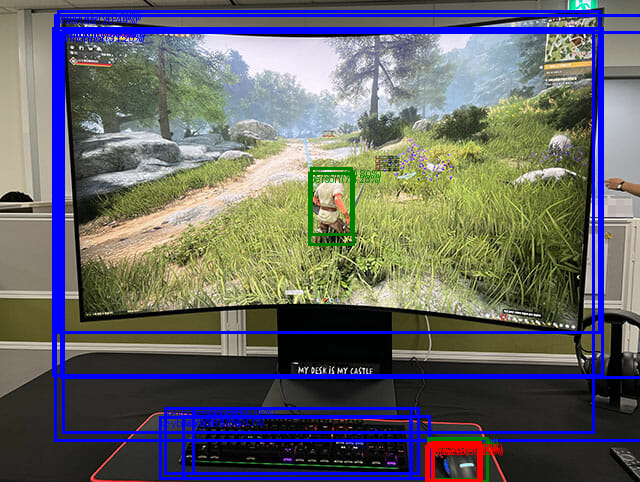

In [4]:
#========== 로컬 이미지 불러오기 ==========
image_array = cv2.imread("sample2.jpg")

#========== 이미지에 박스를 그리기 위한 PIL 객체(Image)로 변환 ==========
# 색반전 변환 : BGR -> RGB
image = Image.fromarray(cv2.cvtColor(image_array.copy(), cv2.COLOR_BGR2RGB))
# 그리기 객체 생성
draw = ImageDraw.Draw(image)

#========== 이미지를 Yolo 입력용 blob으로 변환 ==========
blob = cv2.dnn.blobFromImage(image_array, 1/255.0, (416, 416), swapRB=True, crop=False)

#========== 모델에 넣어주기 ==========
net.setInput(blob)


#========== Yolo 실행 ==========
# unconnected layers : 최종 출력 레이어 지정
out_layer_list = net.getUnconnectedOutLayersNames()

# 저장한 출력 레이어까지 순전파(forward pass) 실행
## 출력 레이어 3개 -> 결과도 3개(82, 94, 106)
detection_list = net.forward(out_layer_list) 
# detection_list = net.forward("yolo_82") #결과값 자체 리턴
# print(detection_list)


#========== 탐지 결과 확인 ==========
# yolo_82에서 뽑아낸 정보

#---------- 1. yolo_82만 ----------
# 출력 레이어 3개 중 yolo_82에서 뽑아낸 정보만 가지고 일단 작성
# prediction_list = detection_list[0]

#---------- 2. yolo_82 + 94, 106 모델도 ----------
# 모델별로 다른 색상 지정
color_list = ["red", "green", "blue"] 

for prediction_list in detection_list:
    color = color_list.pop()

    for prediction in prediction_list:
        # 예측 array 0~3 : 바운딩 박스 좌표
        ## 이때 x,y는 박스의 중간 좌표
        ## yolo의 이미지 좌표는 정규화된 좌표 -> 본래 이미지의 너비,높이 곱해줘 실제 좌표로 변환
        ## 예) center_x	0.5	×	image.width (예: 640)	=	320px
        center_x, center_y, w, h = prediction[:4]  * np.array(
            [image.width, image.height, image.width, image.height]
        )
        # 예측 array 4 : confidence 값
        confidence = prediction[4]
        # 예측 array 5~84 : 각 라벨에 대한 확률값
        score_list = prediction[5:]

        #========== 박스 시작점(왼쪽위) 좌표 계산 ==========
        # 중간 좌표 -> 시작 좌표
        # 음수값이 되는 걸 방지하기 위해 max 적용
        x = max(0, center_x - w/2)  
        y = max(0, center_y - h/2)

        # 점수가 가장 높은 인덱스 반환
        label_index = np.argmax(score_list)
        # 점수 가장 높은 인덱스의 점수를 max_score에 저장
        max_score = score_list[label_index]

        # 가장 높은 인덱스를  레이블 리스트에서 찾아 저장
        label_text= label_list[label_index]
        if max_score > 0 :
            print(label_index, max_score)
            # 박스 그리기 
            draw.rectangle( [ (x,y), (x+w, y+h)], outline=color, width=3)
            draw.text(
                (x, y), "{}({:.2f}%)".format(label_text, max_score*100),
                fill=color)
image

### Yolo 예측 결과 내용

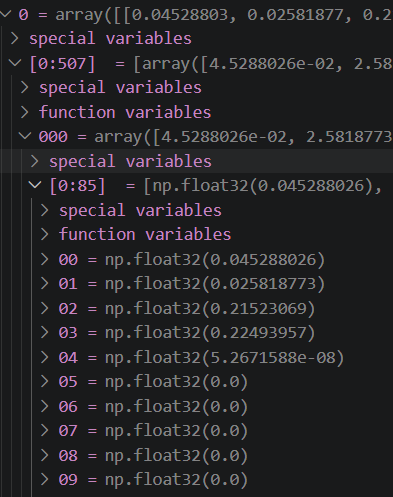
* yolo_숫자 => 숫자가 클수록 리턴받는 array개수(탐색하는 그리드) 많아짐 = 더 상세한 탐지
* 모델별 예측 개수
    * yolo_82 : 507개 
    * yolo_94 : 2028개
    * yolo_106 : 8112개

* 왜? 
    1. feature map 계산
        * 보통 416*416 이미지 사용, 32배 다운 샘플링 => 416 ÷ 32 = 13  (stride=32)
        * 13 × 13 = 169개 그리드 셀
        * 169 × 3 anchors = 507개 예측

* 예측에 들어있는 정보 (85개 값을 array로 리턴)    
    * 0-3 : x, y, w, h 정보
    * 4 : confidence값
    * 5-85 : 클래스에 대한 확률값이 array로 들어있음


* 몇 개의 클래스 제외하고는 대부분 확률값이 0
* confidence * max_score : 허위로 잡아내는 박스를 쉽게 거를 수 있다. 
대체로 이상한데 탐지한 박스들은 confidence가 0이므로 위 값이 0이 될 것
여기서는 사용하지 않겠음

## NMS Box 추가

17
17
17
NMS 박스 결과:  [13 10  6  1]


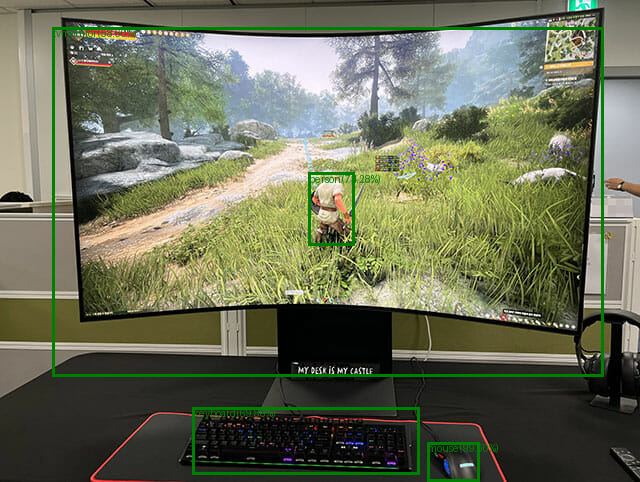

In [5]:
#========== 로컬 이미지 불러오기 ==========
image_array = cv2.imread("sample2.jpg")

#========== 이미지에 박스를 그리기 위한 PIL 객체(Image)로 변환 ==========
# 색반전 변환 : BGR -> RGB
image = Image.fromarray(cv2.cvtColor(image_array.copy(), cv2.COLOR_BGR2RGB))
# 그리기 객체 생성
draw = ImageDraw.Draw(image)

#========== 이미지를 Yolo 입력용 blob으로 변환 ==========
blob = cv2.dnn.blobFromImage(image_array, 1/255.0, (416, 416), swapRB=True, crop=False)

#========== 모델에 넣어주기 ==========
net.setInput(blob)


#========== Yolo 실행 ==========
# unconnected layers : 최종 출력 레이어 지정
out_layer_list = net.getUnconnectedOutLayersNames()

# 저장한 출력 레이어까지 순전파(forward pass) 실행
## 출력 레이어 3개 -> 결과도 3개(82, 94, 106)
detection_list = net.forward(out_layer_list) 
# detection_list = net.forward("yolo_82") #결과값 자체 리턴
# print(detection_list)


#========== 탐지 결과 확인 ==========
# yolo_82에서 뽑아낸 정보

#---------- 1. yolo_82만 ----------
# 출력 레이어 3개 중 yolo_82에서 뽑아낸 정보만 가지고 일단 작성
# prediction_list = detection_list[0]

#---------- 2. yolo_82 + 94, 106 모델도 ----------
# 모델별로 다른 색상 지정
color_list = ["red", "green", "blue"] 

#========== NMS Box 정보 선언 ==========
overlap_bounding_box_list = list()
overlap_score_list = list()
overlap_label_list = list()

for prediction_list in detection_list:
    color = color_list.pop()

    for prediction in prediction_list:
        # 예측 array 0~3 : 바운딩 박스 좌표
        ## 이때 x,y는 박스의 중간 좌표
        ## yolo의 이미지 좌표는 정규화된 좌표 -> 본래 이미지의 너비,높이 곱해줘 실제 좌표로 변환
        ## 예) center_x	0.5	×	image.width (예: 640)	=	320px
        center_x, center_y, w, h = prediction[:4]  * np.array(
            [image.width, image.height, image.width, image.height]
        )
        # 예측 array 4 : confidence 값
        confidence = prediction[4]
        # 예측 array 5~84 : 각 라벨에 대한 확률값
        score_list = prediction[5:]

        #========== 박스 시작점(왼쪽위) 좌표 계산 ==========
        # 중간 좌표 -> 시작 좌표
        # 음수값이 되는 걸 방지하기 위해 max 적용
        x = max(0, center_x - w/2)  
        y = max(0, center_y - h/2)

        label_index = np.argmax(score_list)
        max_score = score_list[label_index]

        label_text= label_list[label_index]
        if max_score > 0 :
            #========== nms 처리할 변수에 일단 저장 ==========
            overlap_bounding_box_list.append([x,y,w,h])
            overlap_label_list.append(label_text)
            overlap_score_list.append(max_score)

print(len(overlap_bounding_box_list))
print(len(overlap_score_list))
print(len(overlap_label_list))

#========== overlap 박스들만 인덱스 저장 ==========      
extracted_index_list = cv2.dnn.NMSBoxes(bboxes= overlap_bounding_box_list, 
                 scores= overlap_score_list, 
                 score_threshold= 0.3, 
                 nms_threshold= 0.4)
print('NMS 박스 결과: ', extracted_index_list)

#========== nms박스만 그리기 ==========
for extracted_index in extracted_index_list:
    label = overlap_label_list[extracted_index]
    score = overlap_score_list[extracted_index]
    bounding_box = overlap_bounding_box_list[extracted_index]
    x, y, w, h = bounding_box

    draw.rectangle( [ (x,y), (x+w, y+h)], outline='green', width= 3)
    draw.text((x,y), "{}({:.2f}%)".format(label, score*100), fill='green')


image

NMS (Non-Maximum Suppression)
* 객체 탐지에서 중복된 바운딩박스를 제거하는 알고리즘
* 동작 원리
    1. confidence score 기준으로 박스를 내림차순 정렬
    2. 가장 높은 점수 박스를 선택
    3. 나머지 박스 중 IoU(겹치는 비율)가 ```nms_threshold```이상인 박스 제거
    4. 남은 박스 중 다음 높은 점수 박스로 반복

## 최종 함수
- Gradio 적용하기 위해 함수로 정의
- 한글 라벨 및 폰트 적용
- 색상 변환 취소

마우스(99.60%)
사람(74.28%)
키보드(69.86%)
TV 모니터(58.60%)


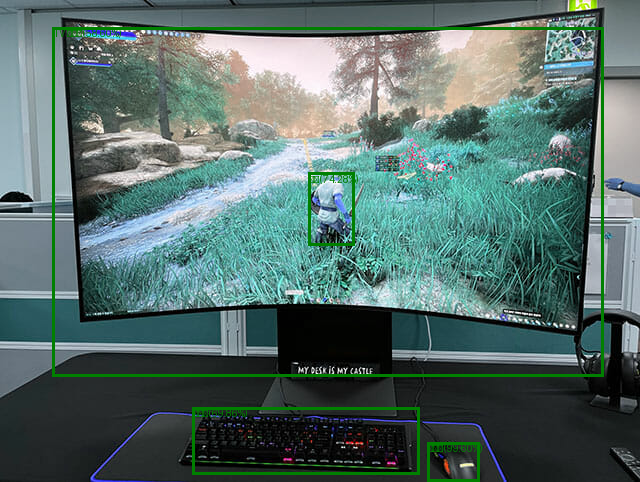

In [6]:
import cv2
import numpy as np
from PIL import Image, ImageDraw
import platform

#========== 경로 설정 ==========
weights_path = "yolo/yolov3.weights"
config_path = "yolo/yolov3.cfg"
# names_path = "yolo/coco.names"
names_path = "yolo/coco_korean.names" #한글 테스트를 위해 변경

#========== 한글 폰트 설정 ==========
def get_font():
    font_size = 20
    try:
        if platform.system() == "Windows":
            return ImageFont.truetype("malgun.ttf", font_size)
        elif platform.system() == "Darwin":  # macOS
            return ImageFont.truetype("AppleGothic.ttf", font_size)
        else:  # Linux 등
            return ImageFont.load_default()
    except IOError:
        return ImageFont.load_default()

font = get_font()

#========== 라벨(이름) 가져오기 ==========
with open(names_path, "r", encoding='utf-8') as name_file:
    label_list = name_file.read().strip().split("\n")
    # strip : 공백 제거 / split: 줄마다 잘라서 리스트로

#========== 모델 불러오기 ==========
net = cv2.dnn.readNet(weights_path, config_path)
# 밖에 선언하는 이유: 그라디오에서 n초마다 한 번씩 계속 호출될텐데 그때마다 계속 선언하면 메모리 부하될수도

def detect_objects(image_array):
    #========== image array -> CV로 읽기 -> PIL로 표시 ==========
    # cv.imread()로 읽기 -> PIL로 표시) 색반전 변환 필요 : BGR -> RGB
    # image = Image.fromarray(cv2.cvtColor(image_array.copy(), cv2.COLOR_BGR2RGB))
    
    #========== image array -> CV ==========
    # gradio 컴포넌트로 입력 받을 경우 = array형태로 입력 받음(RGB) -> 변환해줄 필요 없음
    image = Image.fromarray(image_array.copy())
    

    # 그리기 객체 생성
    draw = ImageDraw.Draw(image)

    #========== 이미지를 Yolo 입력용 blob으로 변환 ==========
    blob = cv2.dnn.blobFromImage(image_array, 1/255.0, (416, 416), swapRB=True, crop=False)

    #========== 모델에 넣어주기 ==========
    net.setInput(blob)

    #========== Yolo 실행 ==========
    # unconnected layers : 최종 출력 레이어 지정
    out_layer_list = net.getUnconnectedOutLayersNames()

    # 저장한 출력 레이어까지 순전파(forward pass) 실행
    ## 출력 레이어 3개 -> 결과도 3개(82, 94, 106)
    detection_list = net.forward(out_layer_list) 

    # 모델별로 다른 색상 지정
    color_list = ["red", "green", "blue"] 

    #========== overlap Box 정보 선언 ==========
    overlap_bounding_box_list = list()
    overlap_score_list = list()
    overlap_label_list = list()

    for prediction_list in detection_list:
        color = color_list.pop()

        for prediction in prediction_list:
            
            center_x, center_y, w, h = prediction[:4]  * np.array(
                [image.width, image.height, image.width, image.height]
            )
            # 예측 array 4 : confidence 값
            confidence = prediction[4]
            # 예측 array 5~84 : 각 라벨에 대한 확률값
            score_list = prediction[5:]

            #========== 박스 시작점(왼쪽위) 좌표 계산 ==========
            # 중간 좌표 -> 시작 좌표
            # 음수값이 되는 걸 방지하기 위해 max 적용
            x = max(0, center_x - w/2)  
            y = max(0, center_y - h/2)

            label_index = np.argmax(score_list)
            max_score = score_list[label_index]

            label_text= label_list[label_index]
            if max_score > 0 :
                #========== nms 처리할 변수에 일단 저장 ==========
                overlap_bounding_box_list.append([x,y,w,h])
                overlap_label_list.append(label_text)
                overlap_score_list.append(max_score)

    #========== nms박스들만 인덱스 저장 ==========      
    extracted_index_list = cv2.dnn.NMSBoxes(
                    bboxes= overlap_bounding_box_list, 
                    scores= overlap_score_list, 
                    score_threshold= 0.3, 
                    nms_threshold= 0.4)

    #========== 중복 제거하고 남은 박스만 그리기 ==========
    for extracted_index in extracted_index_list:
        label = overlap_label_list[extracted_index]
        score = overlap_score_list[extracted_index]
        extracted_bounding_box = overlap_bounding_box_list[extracted_index]
        x, y, w, h = extracted_bounding_box

        draw.rectangle( [ (x,y), (x+w, y+h)], outline='green', width= 3)
        draw.text((x,y), "{}({:.2f}%)".format(label, score*100), fill='green')
        print("{}({:.2f}%)".format(label, score*100))
    return image

# 함수 실행
image_array = cv2.imread('sample2.jpg')
detect_objects(image_array)

## Gradio 화면 구성

In [7]:
import gradio as gr

with gr.Blocks() as demo:
    #========== 이벤트 정의 ==========
    def stream_webcam(image_array):
        result_image = detect_objects(image_array)
        return result_image

    #========== 컴포넌트 ==========
    with gr.Row():
        stream_image = gr.Image(
            label="웹캠",
            sources='webcam',
            # OBS 스튜디오 사용하는 경우
            webcam_options=gr.WebcamOptions(mirror=False),
        )
        result_image = gr.Image(
            label="감지 결과",
            interactive=False,
            type='pil'
        )
    
    #========== 이벤트 트리거 ==========
    stream_image.stream(stream_webcam, inputs=[stream_image], outputs=[result_image])

demo.launch()

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# OpenAI

## 

In [8]:
import cv2
import base64
#========== 이미지 테스트 ==========
# 1. 이미지를 읽기
image_array = cv2.imread('sample2.jpg')
# 2. 이미지를 JPEG로 인코딩, 버퍼에 저장
_, buffer = cv2.imencode(".jpg", image_array)
# 3. base64로 인코딩
image_base64 = base64.b64encode(buffer).decode("utf-8")

In [ ]:
import requests
import cv2
import base64
import os
import dotenv
dotenv.load_dotenv()
YOLO_OPENAI_ENDPOINT = os.getenv('YOLO_OPENAI_ENDPOINT')
YOLO_OPENAI_KEY = os.getenv('YOLO_OPENAI_KEY')

#========== 요청 함수 ==========
def request_openai(image_array):

    #========== 이미지 전처리 ==========
    # 이미지 배열을 JPEG로 인코딩 (메모리 버퍼에 저장)
    _, buffer = cv2.imencode(".jpg", image_array)

    # base64로 인코딩
    image_base64 = base64.b64encode(buffer).decode("utf-8")


    #========== 요청 ==========
    enpoint = "https://fimtrus-foundry.openai.azure.com/openai/deployments/gpt-4.1/chat/completions?api-version=2025-01-01-preview"
    # method
    headers = {
        "Api-key": YOLO_OPENAI_KEY
    }

    body = {
        "messages": [
            {
                "role": "system",
                "content": [
                    {
                        "type": "text",
                        "text": """
                        ### 역할
                        너는 사진 속에서 감지된 물체를 분석하는 AI 봇
                        ### 지침
                        - 분석 결과는 한국어로 답변하세요.
                        - 서론, 결론 제외하고 분석 결과만 답변하세요.
                    """,
                    }
                ],
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": """
                    감지된 물체에 대해서 감지확률과 자세한 설명을 붙여줘.
                    반드시 바운딩 박스로 감지된 물체에 대해서만 설명해야 해.
                    """,
                    },
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"},
                    },
                ],
            },
        ],
        "max_tokens": 4096,
        "temperature": 0.7,
        "top_p": 0.95,
    }

    #========== 응답 처리 ==========
    response = requests.post(enpoint, headers=headers, json=body)

    if not response.ok:
        return None

    response_json = response.json()
    content = response_json["choices"][0]["message"]["content"]
    role = response_json["choices"][0]["message"]["role"]

    return {"role": role, "content": content}

#========== 테스트 ==========
image_array = cv2.imread("sample2.jpg")
request_openai(image_array)

{'role': 'assistant',
 'content': '1. 모니터  \n감지확률: 99%  \n설명: 커브드 형태의 대형 모니터가 바운딩 박스에 감지됨. 화면에는 게임 장면이 표시되고 있으며, 모니터 아래에는 "MY DESK IS MY CASTLE"라는 문구가 붙어 있음. 모니터는 책상 위에 안정적으로 설치되어 있음.\n\n2. 키보드  \n감지확률: 98%  \n설명: 모니터 아래에 RGB 조명이 켜진 키보드가 감지됨. 키보드는 게이밍 키보드로 보이며, 검은색 바탕에 여러 색상의 조명 효과가 나타남.\n\n3. 마우스  \n감지확률: 97%  \n설명: 키보드 오른쪽에 위치한 마우스가 감지됨. 마우스는 검은색으로, 게이밍 용도로 사용되는 것으로 추정됨.\n\n4. 헤드폰  \n감지확률: 96%  \n설명: 모니터 오른쪽에 헤드폰이 감지됨. 헤드폰은 책상 옆에 걸려 있으며, 대형 이어컵이 특징임.'}

## Gradio 화면 구성

In [11]:
import requests
import cv2
import base64
import os
import dotenv
dotenv.load_dotenv()
YOLO_OPENAI_ENDPOINT = os.getenv('YOLO_OPENAI_ENDPOINT')
YOLO_OPENAI_KEY = os.getenv('YOLO_OPENAI_KEY')

def request_openai(image_array):
    #========== 이미지 테스트 ==========
    # 이미지를 JPEG로 인코딩, 버퍼에 저장
    _, buffer = cv2.imencode(".jpg", image_array)
    # base64로 인코딩
    image_base64 = base64.b64encode(buffer).decode("utf-8")


    #========== 요청 구성 ==========
    endpoint = YOLO_OPENAI_ENDPOINT

    headers = {
        "Api-key": YOLO_OPENAI_KEY,
        "Content-Type": "application/json"
    }

    body = {
        "messages": [
            {
                "role": "system",
                "content": [
                    {
                        "type": "text",
                        "text": """
                        ### 역할
                        너는 사진 속에서 감지된 물체를 분석하는 AI 봇
                        ### 지침
                        - 분석 결과는 한국어로 답변하세요.
                        - 서론, 결론 제외하고 분석 결과만 답변하세요.
                    """,
                    }
                ],
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": """
                    감지된 물체에 대해서 감지확률과 자세한 설명을 붙여줘.
                    반드시 바운딩 박스로 감지된 물체에 대해서만 설명해야 해.
                    """,
                    },
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"},
                    },
                ],
            },
        ],
        "max_tokens": 4096,
        "temperature": 0.7,
        "top_p": 0.95,
    }


    response = requests.post(endpoint, headers=headers, json=body)
    # response.text 

    # 예외처리
    if not response.ok:
        pass
        # return None

    response_json = response.json()
    role = response_json["choices"][0]["message"]["role"]
    content = response_json["choices"][0]["message"]["content"]

    return {"role": role, "content": content}

image_array = cv2.imread("sample2.jpg")
request_openai(image_array)

#========== Gradio ==========
with gr.Blocks() as demo:
    #========== 이벤트 ==========
    def click_openai_send(image_array, histories):
        result = request_openai(image_array)
        histories.append(
            {
                "role": "user",
                "content": ""
            }
        )

    #========== Gradio 컴포넌트 ==========
    capture_image = gr.Image(label="캡쳐 화면"   )
    send_openai_button = gr.Button("전송")
    chatbot = gr.Chatbot(label="분석 결과")
    

    #========== 이벤트 트리거 ==========
    send_openai_button.send(click_openai_send, 
                            inputs=[capture_image, chatbot],
                            outputs=[chatbot])
demo.launch()

AttributeError: 'Button' object has no attribute 'send'

Base64란?
- 바이너리 데이터(이미지, 파일) -> 텍스트 문자열로 변환하는 인코딩 방식.
- 컴퓨터에서 이미지는 0과 1로 이루어진 바이너리 데이터인데, 이를 그대로 텍스트 기반 시스템(HTML, JSON, CSS 등)에 넣을 수 없고, 안전하게 보내기 위해 Base64로 변환해서 사용
- 데이터 종료 문자열 등등 제거한 나머지로 만들어짐

Base64의 장점
- ASCII코드로는 깨질 수 있음. but 문자열로만 변환되기 때문에 깨질 일이 없고 특수문자 등에 영향을 받지 않아 안전?하다

Base64 변환 원리

바이너리: 01001000 01100101 ...     
         ↓ 6비트씩 나누기           
6비트 그룹: 010010 000110 0101...   
         ↓ 64개(2^6)의 문자(A-Z, a-z, 0-9, +, /)로 매핑        
Base64: SGVs...             
3바이트(24비트) → 4개의 Base64 문자로 변환되므로, 용량이 약 33% 증가

보내는 방법)
1. body의 image_url에 넣어서 던지면 됨

response.content vs response.text
* response.content : raw 응답. 전송된 바이트 형태 / 스트리밍도 처리
* response.text: 디코딩된 문자열. 텍스트 변환 레이어가 적용됨